In [1]:
#importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Se definen parámetros 

#Probabilidad del bits
p0 = 0.5
p1 = 1-p0

#Número de bits de la secuencia a generar
N=500000 #50millones de bits

#Parámetros de modulación M-ASK
formato='polar' 
M=16
n = int(np.log2(M))
Ts = 0.001
fs=1/Ts
# parámetros

#parámetros para la gráfica de señales
fmuestreo = 100000
fc = 10000
Ac=1



In [3]:
def generador_secuencia(n, p0, p1, semilla=None):
    # validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# ejemplo
secuencia = generador_secuencia(N, p0, p1, semilla=42)
print(secuencia)

[1 0 1 ... 1 1 0]


In [4]:
#Convertidor de datos


def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]


def convertidor_datos(bits, M=4, formato='polar'):
    n = int(np.log2(M))
    
    # asegurar múltiplo de n
    L = len(bits)
    if L % n != 0:
        bits = bits[:L - (L % n)]
    
    # agrupar bits
    grupos = bits.reshape(-1, n)
    
    # generar código Gray
    gray = gray_code(n)
    
    # Crear tabla de lookup vectorizada
    gray_array = np.array([[int(b) for b in codigo] for codigo in gray])
    
    # Convertir grupos a índices usando broadcasting (vectorizado)
    indices = np.where((grupos[:, None, :] == gray_array[None, :, :]).all(axis=2))[1]
    
    # niveles M-ASK
    if formato == 'polar':
        niveles = 2*indices - (M - 1)
    elif formato == 'unipolar':
        niveles = indices
    else:
        raise ValueError("Formato debe ser 'polar' o 'unipolar'")
    
    return niveles


Ik = convertidor_datos(secuencia, M, formato)
print(Ik)
    

[ 11  -5 -13 ...   9  11  -7]


In [5]:

gray = gray_code(n)
p_simbolos = []
for codigo in gray:
    prob = 1.0
    for bit in codigo:
        if bit == '0':
            prob *= p0
        else:
            prob *= p1
    p_simbolos.append(prob)
p_simbolos = np.array(p_simbolos)

# Generar niveles M-ASK según el formato definido
indices = np.arange(M)
if formato == 'polar':
    niveles_ask = 2*indices - (M - 1)
elif formato == 'unipolar':
    niveles_ask = indices
else:
    raise ValueError("Formato debe ser 'polar' o 'unipolar'")

# Verificar que las probabilidades suman 1
print(f"Formato: {formato}")
print(f"Suma de probabilidades: {np.sum(p_simbolos):.6f}")
print(f"\nProbabilidades de cada símbolo:")
for i, (nivel, prob) in enumerate(zip(niveles_ask, p_simbolos)):
    print(f"  a_k = {nivel:3d}, código Gray = {gray[i]}, p(a_k) = {prob:.6f}")


Formato: polar
Suma de probabilidades: 1.000000

Probabilidades de cada símbolo:
  a_k = -15, código Gray = 0000, p(a_k) = 0.062500
  a_k = -13, código Gray = 0001, p(a_k) = 0.062500
  a_k = -11, código Gray = 0011, p(a_k) = 0.062500
  a_k =  -9, código Gray = 0010, p(a_k) = 0.062500
  a_k =  -7, código Gray = 0110, p(a_k) = 0.062500
  a_k =  -5, código Gray = 0111, p(a_k) = 0.062500
  a_k =  -3, código Gray = 0101, p(a_k) = 0.062500
  a_k =  -1, código Gray = 0100, p(a_k) = 0.062500
  a_k =   1, código Gray = 1100, p(a_k) = 0.062500
  a_k =   3, código Gray = 1101, p(a_k) = 0.062500
  a_k =   5, código Gray = 1111, p(a_k) = 0.062500
  a_k =   7, código Gray = 1110, p(a_k) = 0.062500
  a_k =   9, código Gray = 1010, p(a_k) = 0.062500
  a_k =  11, código Gray = 1011, p(a_k) = 0.062500
  a_k =  13, código Gray = 1001, p(a_k) = 0.062500
  a_k =  15, código Gray = 1000, p(a_k) = 0.062500


In [6]:
#Generación de valores de ni
ak2_mean = np.sum(niveles_ask**2 * p_simbolos)
print(f"\nValor cuadrático medio= {ak2_mean:.6f}")

# Rango de SNR por bit en dB
gamma_b_dB = np.arange(5, 31, 1)  # de 5 dB a 20 dB en pasos de 1 dB

# Diccionario para almacenar los ruidos y señales para cada SNR
resultados = {}

for snr_db in gamma_b_dB:
    # Convertir SNR de dB a escala lineal
    gamma_b_lineal = 10**(snr_db / 10)
    
    # Calcular la varianza del ruido según la fórmula
    # σ^2 = (A_c^2 * (a_k^2)̅) / (2 * γ_b * log_2(M))
    sigma2 = (Ac**2 * ak2_mean) / (2 * gamma_b_lineal * np.log2(M))
    sigma = np.sqrt(sigma2)
    
    # Generar valores de ruido ni con media=0 y varianza=σ^2
    ni = np.random.normal(0, sigma, size=len(Ik))
    
    # Guardar en diccionario
    resultados[snr_db] = {
        'ni': ni,
        'sigma2': sigma2,
        'sigma': sigma
    }

print(f"\nRuido generado para SNR de {gamma_b_dB[0]} dB a {gamma_b_dB[-1]} dB")
print(f"Ejemplo para SNR = 10 dB:")
print(f"  σ^2 = {resultados[10]['sigma2']:.6f}")
print(f"  σ = {resultados[10]['sigma']:.6f}")
print(f"  Primeros 5 valores de ni: {resultados[10]['ni'][:5]}")


Valor cuadrático medio= 85.000000

Ruido generado para SNR de 5 dB a 30 dB
Ejemplo para SNR = 10 dB:
  σ^2 = 1.062500
  σ = 1.030776
  Primeros 5 valores de ni: [-0.08389009  0.32418639  0.6492971  -0.53858302 -0.43989073]


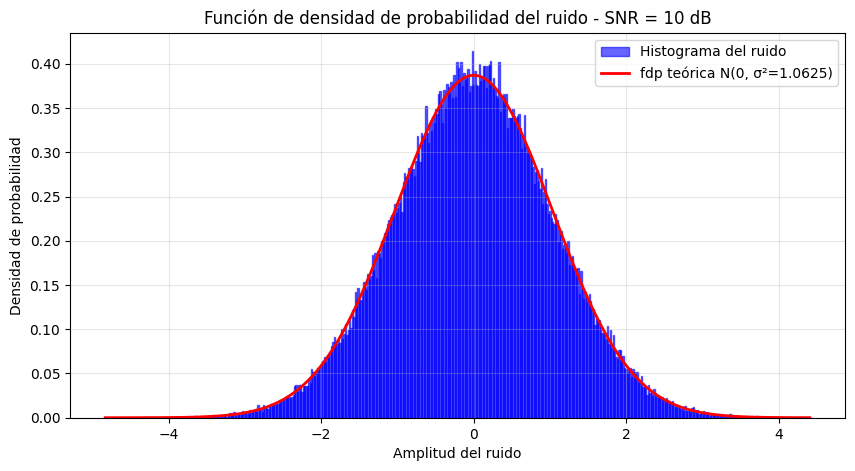

In [7]:
# Gráfica de la fdp del ruido para SNR = 10 dB
snr_plot = 10
ni_plot = resultados[snr_plot]['ni']
sigma_plot = resultados[snr_plot]['sigma']

x = np.linspace(ni_plot.min(), ni_plot.max(), 1000)
fdp_teorica = (1/(sigma_plot * np.sqrt(2*np.pi))) * np.exp(-x**2 / (2*sigma_plot**2))

plt.figure(figsize=(10, 5))
plt.hist(ni_plot, bins=500, density=True, alpha=0.6, color='blue', edgecolor='blue', label='Histograma del ruido')
plt.plot(x, fdp_teorica, 'r-', linewidth=2, label=f'fdp teórica N(0, σ²={sigma_plot**2:.4f})')
plt.xlabel('Amplitud del ruido')
plt.ylabel('Densidad de probabilidad')
plt.title(f'Función de densidad de probabilidad del ruido - SNR = {snr_plot} dB')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Salida del canal AWGN: y_i = Ik + ni

# Calcular la señal recibida para cada valor de SNR
for snr_db in gamma_b_dB:
    # Señal recibida = símbolos transmitidos + ruido
    yi = Ik + resultados[snr_db]['ni']
    
    # Guardar en el diccionario de resultados
    resultados[snr_db]['yi'] = yi

# Mostrar ejemplo para SNR = 10 dB
print(f"Ejemplo para SNR = 10 dB:")
print(f"Símbolos transmitidos Ik (primeros 5): {Ik[:5]}")
print(f"Ruido ni (primeros 5):                 {resultados[10]['ni'][:5]}")
print(f"Señal recibida yi (primeros 5):        {resultados[10]['yi'][:5]}")

Ejemplo para SNR = 10 dB:
Símbolos transmitidos Ik (primeros 5): [ 11  -5 -13   1  11]
Ruido ni (primeros 5):                 [-0.08389009  0.32418639  0.6492971  -0.53858302 -0.43989073]
Señal recibida yi (primeros 5):        [ 10.91610991  -4.67581361 -12.3507029    0.46141698  10.56010927]


In [9]:
# Cuantizador - Búsqueda binaria vectorizada
umbrales = (niveles_ask[:-1] + niveles_ask[1:]) / 2

for snr_db in gamma_b_dB:
    yi = resultados[snr_db]['yi']
    indices = np.digitize(yi, umbrales)
    Ik_estimado = niveles_ask[indices]
    resultados[snr_db]['Ik_est'] = Ik_estimado

print(f"Umbrales de cuantización: {umbrales}")
print(f"\nEjemplo para SNR = 10 dB:")
print(f"Ik transmitido:  {Ik[:15]}")
print(f"Ik estimado:     {resultados[10]['Ik_est'][:15].astype(int)}")
print(f"Errores:         {np.sum(Ik != resultados[10]['Ik_est'])} de {len(Ik)} símbolos")

Umbrales de cuantización: [-14. -12. -10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.   8.  10.  12.
  14.]

Ejemplo para SNR = 10 dB:
Ik transmitido:  [ 11  -5 -13   1  11  11  15  -5 -15 -13  -7   1  15   5  -1]
Ik estimado:     [ 11  -5 -13   1  11  11  15  -5 -15 -13  -7   1  15   7   1]
Errores:         38845 de 125000 símbolos


In [10]:
# Demapeador: símbolos a bits (OPTIMIZADO - bajo consumo de memoria)
def demapeador_simbolos(simbolos, M=4, formato='polar'):
    n = int(np.log2(M))
    gray = gray_code(n)
    
    # Convertir símbolos a índices
    if formato == 'polar':
        indices = ((simbolos + (M - 1)) / 2).astype(int)
    elif formato == 'unipolar':
        indices = simbolos.astype(int)
    else:
        raise ValueError("Formato debe ser 'polar' o 'unipolar'")
    
    # Crear tabla de lookup compacta
    lookup_table = np.array([[int(b) for b in codigo] for codigo in gray], dtype=np.int8)
    
    # Procesar por chunks para evitar consumo excesivo de memoria
    chunk_size = 1000000
    num_chunks = (len(indices) + chunk_size - 1) // chunk_size
    
    bits_estimados = np.empty(len(indices) * n, dtype=np.int8)
    
    for i in range(num_chunks):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(indices))
        chunk_indices = indices[start:end]
        
        bits_chunk = lookup_table[chunk_indices].flatten()
        bits_estimados[start*n:end*n] = bits_chunk
    
    return bits_estimados

for snr_db in gamma_b_dB:
    Ik_est = resultados[snr_db]['Ik_est']
    bits_estimados = demapeador_simbolos(Ik_est, M, formato)
    resultados[snr_db]['bits_est'] = bits_estimados

print(f"Ejemplo para SNR = 10 dB:")
print(f"Bits transmitidos (primeros 20): {secuencia[:20]}")
print(f"Bits estimados (primeros 20):    {resultados[10]['bits_est'][:20]}")
print(f"Errores de bits: {np.sum(secuencia[:len(resultados[10]['bits_est'])] != resultados[10]['bits_est'])} de {len(resultados[10]['bits_est'])} bits")

Ejemplo para SNR = 10 dB:
Bits transmitidos (primeros 20): [1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1]
Bits estimados (primeros 20):    [1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1]
Errores de bits: 39274 de 500000 bits


#de bits estimados: 500000


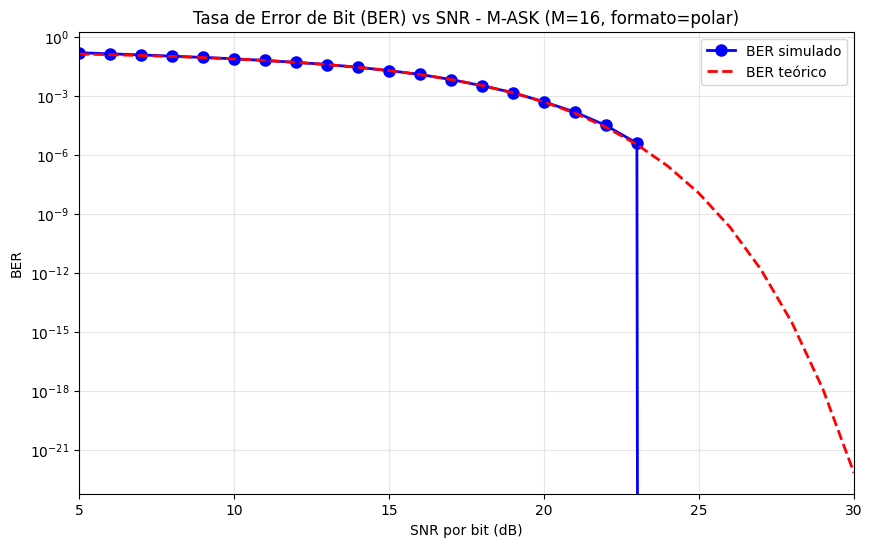


Resultados BER:
SNR (dB)   BER simulado    BER teórico    
5          1.600700e-01    1.371971e-01   
6          1.409760e-01    1.266702e-01   
7          1.240220e-01    1.153602e-01   
8          1.070680e-01    1.033447e-01   
9          9.242600e-02    9.075848e-02   
10         7.854800e-02    7.780675e-02   
11         6.456800e-02    6.477342e-02   
12         5.189400e-02    5.202151e-02   
13         4.021200e-02    3.997821e-02   
14         2.899000e-02    2.909842e-02   
15         1.984200e-02    1.980334e-02   
16         1.262800e-02    1.239980e-02   
17         6.942000e-03    6.999569e-03   
18         3.374000e-03    3.472096e-03   
19         1.488000e-03    1.465448e-03   
20         5.140000e-04    5.053069e-04   
21         1.540000e-04    1.352374e-04   
22         3.200000e-05    2.633610e-05   
23         4.000000e-06    3.440134e-06   
24         0.000000e+00    2.720401e-07   
25         0.000000e+00    1.144497e-08   
26         0.000000e+00    2.176917e-

In [11]:
# Cálculo y gráfica del BER
from scipy.special import erfc

BER = []
bits_tx = secuencia[:len(Ik)*n]

for snr_db in gamma_b_dB:
    bits_est = resultados[snr_db]['bits_est']
    errores = np.sum(bits_tx != bits_est)
    ber = errores / len(bits_tx)
    BER.append(ber)
    resultados[snr_db]['BER'] = ber
print("#de bits estimados:",len(bits_est))
BER = np.array(BER)

# BER teórico
L = np.log2(M)
BER_teorico = []

for snr_db in gamma_b_dB:
    gamma_b_lin = 10**(snr_db / 10)
    argumento = np.sqrt((6 * L / (M**2 - 1)) * gamma_b_lin)
    Q = 0.5 * erfc(argumento / np.sqrt(2))
    pb_teorico = (2 / L) * (1 - 1/M) * Q
    BER_teorico.append(pb_teorico)

BER_teorico = np.array(BER_teorico)

plt.figure(figsize=(10, 6))
plt.semilogy(gamma_b_dB, BER, 'bo-', linewidth=2, markersize=8, label='BER simulado')
plt.semilogy(gamma_b_dB, BER_teorico, 'r--', linewidth=2, label='BER teórico')
plt.xlabel('SNR por bit (dB)')
plt.ylabel('BER')
plt.title(f'Tasa de Error de Bit (BER) vs SNR - M-ASK (M={M}, formato={formato})')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.xlim([gamma_b_dB[0], gamma_b_dB[-1]])
plt.show()

print(f"\nResultados BER:")
print(f"{'SNR (dB)':<10} {'BER simulado':<15} {'BER teórico':<15}")
for snr_db, ber_sim, ber_teo in zip(gamma_b_dB, BER, BER_teorico):
    print(f"{snr_db:<10d} {ber_sim:<15.6e} {ber_teo:<15.6e}")

In [12]:
!pip install sounddevice


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# TRANSMISIÓN DE VOZ CON M-ASK

Esta sección implementa un sistema completo de transmisión de voz usando modulación M-ASK con canal AWGN.

In [13]:
import sounddevice as sd
from scipy.io import wavfile
from scipy import signal

SAMPLE_RATE = 8000
CHANNELS = 1
BITS_PER_SAMPLE = 8
SNR_VALUES = [5, 10, 15, 20, 25]

print(f"Parámetros de audio:")
print(f"  Frecuencia de muestreo: {SAMPLE_RATE} Hz")
print(f"  Canales: {CHANNELS} (Mono)")
print(f"  Cuantización: {BITS_PER_SAMPLE} bits")
print(f"  SNR a probar: {SNR_VALUES} dB")

Parámetros de audio:
  Frecuencia de muestreo: 8000 Hz
  Canales: 1 (Mono)
  Cuantización: 8 bits
  SNR a probar: [5, 10, 15, 20, 25] dB


In [14]:
def record_audio():
    print("Grabando audio... Presiona Enter para detener.")
    recording = []
    
    def callback(indata, frames, time, status):
        if status:
            print(status)
        recording.append(indata.copy())
    
    stream = sd.InputStream(samplerate=SAMPLE_RATE, channels=CHANNELS, callback=callback, dtype='float32')
    with stream:
        input()
    
    audio = np.concatenate(recording, axis=0).flatten()
    print(f"Grabación completa: {len(audio)} muestras ({len(audio)/SAMPLE_RATE:.2f} segundos)")
    return audio

def load_audio(filepath):
    sample_rate, audio = wavfile.read(filepath)
    
    if audio.dtype == np.int16:
        audio = audio.astype(float) / 32768.0
    elif audio.dtype == np.uint8:
        audio = (audio.astype(float) / 255.0) * 2.0 - 1.0
    
    if len(audio.shape) > 1:
        audio = audio.mean(axis=1)
    
    if sample_rate != SAMPLE_RATE:
        from scipy.signal import resample
        num_samples = int(len(audio) * SAMPLE_RATE / sample_rate)
        audio = resample(audio, num_samples)
        print(f"Audio remuestreado de {sample_rate} Hz a {SAMPLE_RATE} Hz")
    
    print(f"Audio cargado: {len(audio)} muestras ({len(audio)/SAMPLE_RATE:.2f} segundos)")
    return audio

In [15]:
def audio_to_bits(audio_float):
    audio_clipped = np.clip(audio_float, -1.0, 1.0)
    audio_uint8 = ((audio_clipped + 1.0) / 2.0 * 255).astype(np.uint8)
    bits = np.unpackbits(audio_uint8)
    return bits, audio_uint8

def bits_to_audio(bits, original_length):
    bits_padded = bits[:original_length * 8]
    audio_uint8 = np.packbits(bits_padded)
    audio_float = (audio_uint8.astype(float) / 255.0) * 2.0 - 1.0
    audio_float = np.clip(audio_float, -1.0, 1.0)
    return audio_float

In [16]:
def transmit_voice(bits, SNR_dB_list=SNR_VALUES):
    print(f"Transmitiendo {len(bits)} bits ({len(bits)//4} símbolos)...")
    
    simbolos_tx = convertidor_datos(bits, M, formato)
    
    resultados_tx = {}
    
    for snr_db in SNR_dB_list:
        gamma_b_lineal = 10**(snr_db / 10)
        sigma2 = (Ac**2 * ak2_mean) / (2 * gamma_b_lineal * np.log2(M))
        sigma = np.sqrt(sigma2)
        
        ni = np.random.normal(0, sigma, size=len(simbolos_tx))
        yi = simbolos_tx + ni
        
        indices_rx = np.digitize(yi, umbrales)
        simbolos_rx = niveles_ask[indices_rx]
        
        bits_rx = demapeador_simbolos(simbolos_rx, M, formato)
        
        bits_tx_truncated = bits[:len(bits_rx)]
        BER = np.sum(bits_tx_truncated != bits_rx) / len(bits_rx)
        
        resultados_tx[snr_db] = {
            'simbolos_tx': simbolos_tx,
            'simbolos_rx': simbolos_rx,
            'bits_rx': bits_rx,
            'yi': yi,
            'BER': BER,
            'sigma': sigma
        }
        
        print(f"  SNR = {snr_db:2d} dB: BER = {BER:.4e}")
    
    return resultados_tx, simbolos_tx

In [17]:
def playback_comparison(audio_original, resultados_audio, save_files=True, output_dir='./voice_results'):
    import os
    
    if save_files:
        os.makedirs(output_dir, exist_ok=True)
        wavfile.write(f"{output_dir}/original.wav", SAMPLE_RATE, (audio_original * 32767).astype(np.int16))
        print(f"Audio original guardado en: {output_dir}/original.wav")
    
    print("\n" + "="*60)
    print("COMPARACIÓN DE AUDIO")
    print("="*60)
    
    print("\nReproduciendo audio ORIGINAL...")
    sd.play(audio_original, SAMPLE_RATE)
    sd.wait()
    input("Presiona Enter para continuar...")
    
    for snr_db in sorted(resultados_audio.keys()):
        audio_rx = resultados_audio[snr_db]['audio']
        ber = resultados_audio[snr_db]['BER']
        
        print(f"\nReproduciendo SNR = {snr_db} dB (BER = {ber:.4e})")
        sd.play(audio_rx, SAMPLE_RATE)
        sd.wait()
        
        if save_files:
            filename = f"{output_dir}/snr_{snr_db}dB_BER_{ber:.2e}.wav"
            wavfile.write(filename, SAMPLE_RATE, (audio_rx * 32767).astype(np.int16))
            print(f"  Guardado: {filename}")
        
        input("Presiona Enter para siguiente...")
    
    print("\n" + "="*60)
    print("REPRODUCCIÓN COMPLETA")
    print("="*60)

In [18]:
def visualize_voice_results(audio_original, resultados_audio):
    num_snr = len(resultados_audio)
    snr_values = sorted(resultados_audio.keys())
    
    fig, axes = plt.subplots(num_snr + 1, 2, figsize=(14, 3*(num_snr+1)))
    
    time = np.arange(len(audio_original)) / SAMPLE_RATE
    
    axes[0, 0].plot(time, audio_original, linewidth=0.5)
    axes[0, 0].set_title('Audio Original - Forma de Onda')
    axes[0, 0].set_xlabel('Tiempo (s)')
    axes[0, 0].set_ylabel('Amplitud')
    axes[0, 0].grid(True, alpha=0.3)
    
    f, t, Sxx = signal.spectrogram(audio_original, SAMPLE_RATE, nperseg=256)
    axes[0, 1].pcolormesh(t, f, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
    axes[0, 1].set_title('Audio Original - Espectrograma')
    axes[0, 1].set_ylabel('Frecuencia (Hz)')
    axes[0, 1].set_xlabel('Tiempo (s)')
    
    for idx, snr_db in enumerate(snr_values, start=1):
        audio_rx = resultados_audio[snr_db]['audio']
        ber = resultados_audio[snr_db]['BER']
        
        axes[idx, 0].plot(time, audio_rx, linewidth=0.5, color='orange')
        axes[idx, 0].set_title(f'SNR = {snr_db} dB - BER = {ber:.4e}')
        axes[idx, 0].set_xlabel('Tiempo (s)')
        axes[idx, 0].set_ylabel('Amplitud')
        axes[idx, 0].grid(True, alpha=0.3)
        
        f, t, Sxx = signal.spectrogram(audio_rx, SAMPLE_RATE, nperseg=256)
        axes[idx, 1].pcolormesh(t, f, 10*np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
        axes[idx, 1].set_ylabel('Frecuencia (Hz)')
        axes[idx, 1].set_xlabel('Tiempo (s)')
    
    plt.tight_layout()
    plt.show()
    
    ber_values = [resultados_audio[snr]['BER'] for snr in snr_values]
    plt.figure(figsize=(10, 6))
    plt.semilogy(snr_values, ber_values, 'bo-', linewidth=2, markersize=8, label='BER - Transmisión de Voz')
    plt.xlabel('SNR (dB)')
    plt.ylabel('BER')
    plt.title('Transmisión de Voz - BER vs SNR')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.xlim([snr_values[0], snr_values[-1]])
    plt.show()

               TRANSMISIÓN DE VOZ - SISTEMA M-ASK



¿Grabar audio (G) o Cargar archivo WAV (C)?  G


Grabando audio... Presiona Enter para detener.


Grabación completa: 35152 muestras (4.39 segundos)

Audio capturado: 35152 muestras (4.39 seg)

Convirtiendo audio a bits...
Stream de bits: 281216 bits
Símbolos M-ASK: 70304 símbolos (M=16)

Transmitiendo a través del canal M-ASK...
Transmitiendo 281216 bits (70304 símbolos)...
  SNR =  5 dB: BER = 1.6703e-01
  SNR = 10 dB: BER = 8.1916e-02
  SNR = 15 dB: BER = 2.0454e-02
  SNR = 20 dB: BER = 5.0851e-04
  SNR = 25 dB: BER = 0.0000e+00

Reconstruyendo audio...

Generando visualizaciones...


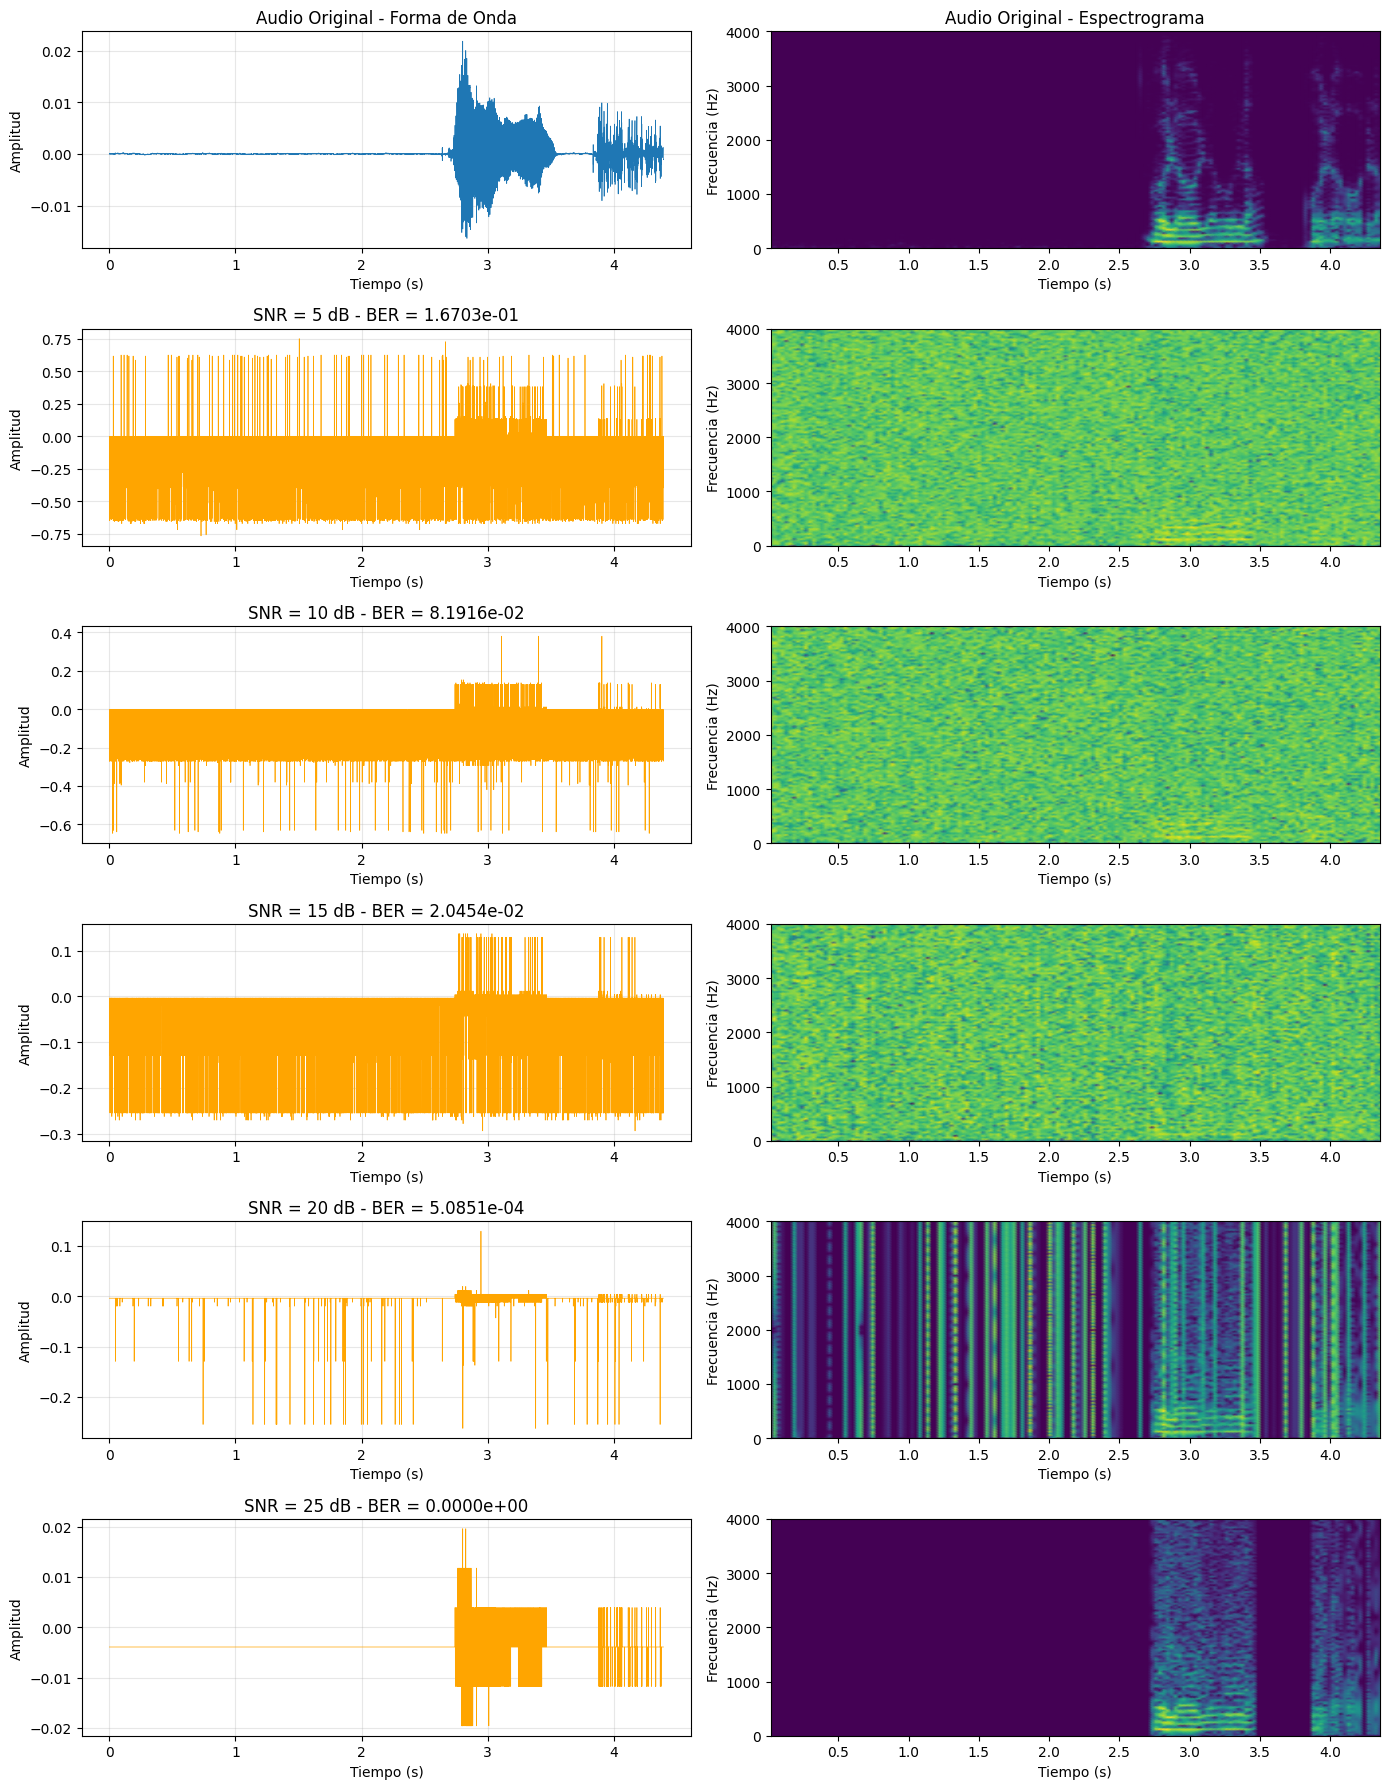

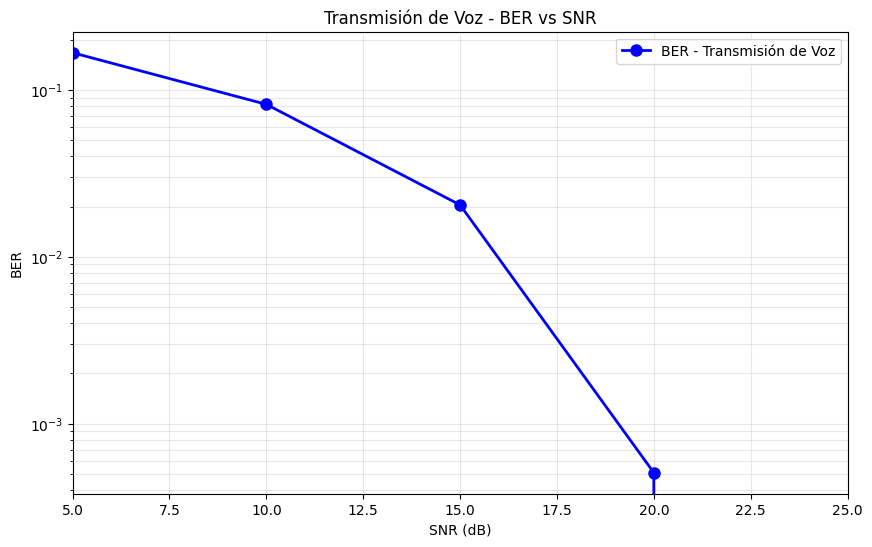


¿Reproducir audio? (S/N):  S


Audio original guardado en: ./voice_results/original.wav

COMPARACIÓN DE AUDIO

Reproduciendo audio ORIGINAL...


Presiona Enter para continuar... 



Reproduciendo SNR = 5 dB (BER = 1.6703e-01)
  Guardado: ./voice_results/snr_5dB_BER_1.67e-01.wav


Presiona Enter para siguiente... 


...


Reproduciendo SNR = 20 dB (BER = 5.0851e-04)
  Guardado: ./voice_results/snr_20dB_BER_5.09e-04.wav


Presiona Enter para siguiente... 



Reproduciendo SNR = 25 dB (BER = 0.0000e+00)
  Guardado: ./voice_results/snr_25dB_BER_0.00e+00.wav


Presiona Enter para siguiente... 



REPRODUCCIÓN COMPLETA

                    TRANSMISIÓN COMPLETADA


In [19]:
print("="*70)
print(" "*15 + "TRANSMISIÓN DE VOZ - SISTEMA M-ASK")
print("="*70)

choice = input("\n¿Grabar audio (G) o Cargar archivo WAV (C)? ").strip().upper()

if choice == 'G':
    audio_original = record_audio()
elif choice == 'C':
    filepath = input("Ingresa la ruta del archivo WAV: ").strip()
    audio_original = load_audio(filepath)
else:
    print("Opción inválida. Usando audio de ejemplo (tono de 440 Hz)")
    duration = 3.0
    t = np.arange(int(duration * SAMPLE_RATE)) / SAMPLE_RATE
    audio_original = 0.5 * np.sin(2 * np.pi * 440 * t)

print(f"\nAudio capturado: {len(audio_original)} muestras ({len(audio_original)/SAMPLE_RATE:.2f} seg)")

print("\nConvirtiendo audio a bits...")
bits_tx, audio_uint8 = audio_to_bits(audio_original)
print(f"Stream de bits: {len(bits_tx)} bits")
print(f"Símbolos M-ASK: {len(bits_tx)//4} símbolos (M={M})")

print("\nTransmitiendo a través del canal M-ASK...")
resultados_tx, simbolos_tx = transmit_voice(bits_tx, SNR_VALUES)

print("\nReconstruyendo audio...")
resultados_audio = {}
for snr_db, resultado in resultados_tx.items():
    bits_rx = resultado['bits_rx']
    audio_rx = bits_to_audio(bits_rx, len(audio_original))
    resultados_audio[snr_db] = {
        'audio': audio_rx,
        'BER': resultado['BER']
    }

print("\nGenerando visualizaciones...")
visualize_voice_results(audio_original, resultados_audio)

playback = input("\n¿Reproducir audio? (S/N): ").strip().upper()
if playback == 'S':
    playback_comparison(audio_original, resultados_audio, save_files=True)

print("\n" + "="*70)
print(" "*20 + "TRANSMISIÓN COMPLETADA")
print("="*70)